In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt # for making figures
%matplotlib inline

In [2]:
# read in all the words
words = open('names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [3]:
len(words)

32033

In [4]:
# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)
print(itos)
print(vocab_size)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


In [5]:
# build the dataset
block_size = 3 # context length: how many characters do we take to predict the next one?

def build_dataset(words):  
  X, Y = [], []
  
  for w in words:
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr,  Ytr  = build_dataset(words[:n1])     # 80%
Xdev, Ydev = build_dataset(words[n1:n2])   # 10%
Xte,  Yte  = build_dataset(words[n2:])     # 10%

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [6]:
# MLP revisited
n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 200 # the number of neurons in the hidden layer of the MLP

g = torch.Generator().manual_seed(2147483647) # for reproducibility
C  = torch.randn((vocab_size, n_embd),            generator=g)
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) 
b1 = torch.randn(n_hidden,                        generator=g)
W2 = torch.randn((n_hidden, vocab_size),          generator=g)
b2 = torch.randn(vocab_size,                      generator=g)

parameters = [C, W1, b1, W2, b2]
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
  p.requires_grad = True

11897


In [7]:
# Same optimization
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):
    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y

    # forward pass
    emb = C[Xb] # embed characters into vectors
    embcat = emb.view(emb.shape[0], -1) # contatenate the vectors
    hpreact = embcat @ W1 + b1 # hidden layer pre-activation
    h = torch.tanh(hpreact) # hidden layer
    logits = h @ W2 + b2 # output layer
    loss = F.cross_entropy(logits, Yb) # loss function

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = 0.1 if i < 100000 else 0.01 # step learning rate decay
    for p in parameters:
        p.data += -lr * p.grad

    # track stats
    if i % 10000 == 0: # print every once in a while
        print(f'{i:7d} /{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())

      0 / 200000: 27.8817
  10000 / 200000: 2.7474
  20000 / 200000: 2.5568
  30000 / 200000: 2.8285
  40000 / 200000: 2.0703
  50000 / 200000: 2.4741
  60000 / 200000: 2.3801
  70000 / 200000: 2.1771
  80000 / 200000: 2.3672
  90000 / 200000: 2.3136
 100000 / 200000: 2.0238
 110000 / 200000: 2.3151
 120000 / 200000: 1.8824
 130000 / 200000: 2.4243
 140000 / 200000: 2.2494
 150000 / 200000: 2.1619
 160000 / 200000: 2.0668
 170000 / 200000: 1.8022
 180000 / 200000: 2.0017
 190000 / 200000: 1.8885


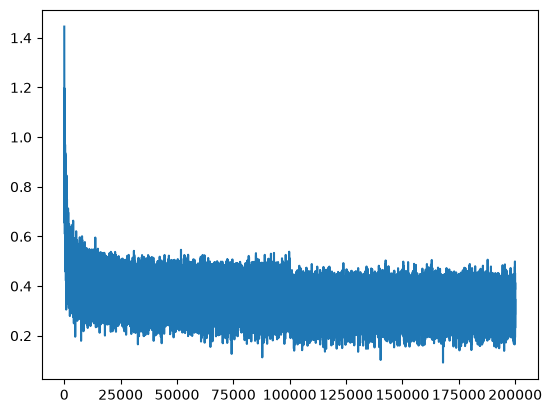

In [8]:
plt.plot(lossi)

In [9]:
@torch.no_grad() # this decorator disables gradient tracking
def split_loss(split):
  x,y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
  }[split]
  emb = C[x] # (N, block_size, n_embd)
  embcat = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
  hpreact = embcat @ W1 + b1
  h = torch.tanh(hpreact) # (N, n_hidden)
  logits = h @ W2 + b2 # (N, vocab_size)
  loss = F.cross_entropy(logits, y)
  print(split, loss.item())

split_loss('train')
split_loss('val')

train 2.1238253116607666
val 2.1623337268829346


In [ ]:
# Fixing the initial loss
# It should be predictable and we can calculate the rough estimate.
# For example, if we have 27 characters, the initial loss should be -torch(log(1/27)) = 3.2958368660043297
# Loss is bad in the start because the bunch values of logits vary and the softmax function is very 
# sensitive to the values of logits.
# In this case, we can fix the initial loss by initializing the weights of the output layer to be zero.
# So b2 should be initialized to zero and W2 should be initialized to small values.

In [12]:
# MLP revisited
n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 200 # the number of neurons in the hidden layer of the MLP

g = torch.Generator().manual_seed(2147483647) # for reproducibility
C  = torch.randn((vocab_size, n_embd),            generator=g)
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) 
b1 = torch.randn(n_hidden,                        generator=g)
W2 = torch.randn((n_hidden, vocab_size),          generator=g) * 0.01
b2 = torch.randn(vocab_size,                      generator=g) * 0

parameters = [C, W1, b1, W2, b2]
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
  p.requires_grad = True

11897


In [13]:
# Same optimization
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):
    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y

    # forward pass
    emb = C[Xb] # embed characters into vectors
    embcat = emb.view(emb.shape[0], -1) # contatenate the vectors
    hpreact = embcat @ W1 + b1 # hidden layer pre-activation
    h = torch.tanh(hpreact) # hidden layer
    logits = h @ W2 + b2 # output layer
    loss = F.cross_entropy(logits, Yb) # loss function

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = 0.1 if i < 100000 else 0.01 # step learning rate decay
    for p in parameters:
        p.data += -lr * p.grad

    # track stats
    if i % 10000 == 0: # print every once in a while
        print(f'{i:7d} /{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())

      0 / 200000: 3.3221
  10000 / 200000: 2.1900
  20000 / 200000: 2.4196
  30000 / 200000: 2.6067
  40000 / 200000: 2.0601
  50000 / 200000: 2.4988
  60000 / 200000: 2.3902
  70000 / 200000: 2.1344
  80000 / 200000: 2.3369
  90000 / 200000: 2.1299
 100000 / 200000: 1.8329
 110000 / 200000: 2.2053
 120000 / 200000: 1.8540
 130000 / 200000: 2.4566
 140000 / 200000: 2.1879
 150000 / 200000: 2.1118
 160000 / 200000: 1.8956
 170000 / 200000: 1.8644
 180000 / 200000: 2.0326
 190000 / 200000: 1.8417


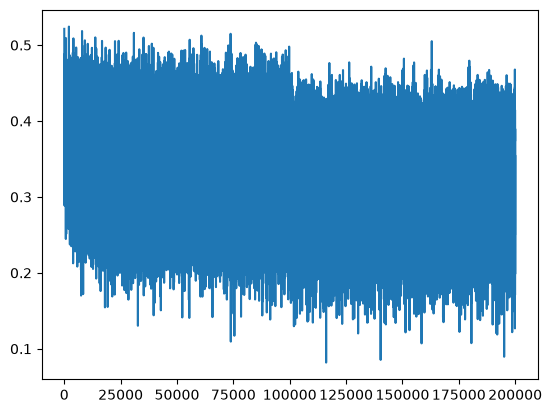

In [14]:
plt.plot(lossi)

In [16]:
@torch.no_grad() # this decorator disables gradient tracking
def split_loss(split):
  x,y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
  }[split]
  emb = C[x] # (N, block_size, n_embd)
  embcat = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
  hpreact = embcat @ W1 + b1
  h = torch.tanh(hpreact) # (N, n_hidden)
  logits = h @ W2 + b2 # (N, vocab_size)
  loss = F.cross_entropy(logits, y)
  print(split, loss.item())

split_loss('train')
split_loss('val')

train 2.069589138031006
val 2.1310746669769287


In [ ]:
# Now we will look if tanh layer has any dead neurons. 
# We will look at the distribution of the pre-activation values of the hidden layer. 
# If there are dead neurons, we will see a lot of values that are very close to -1 or 1.

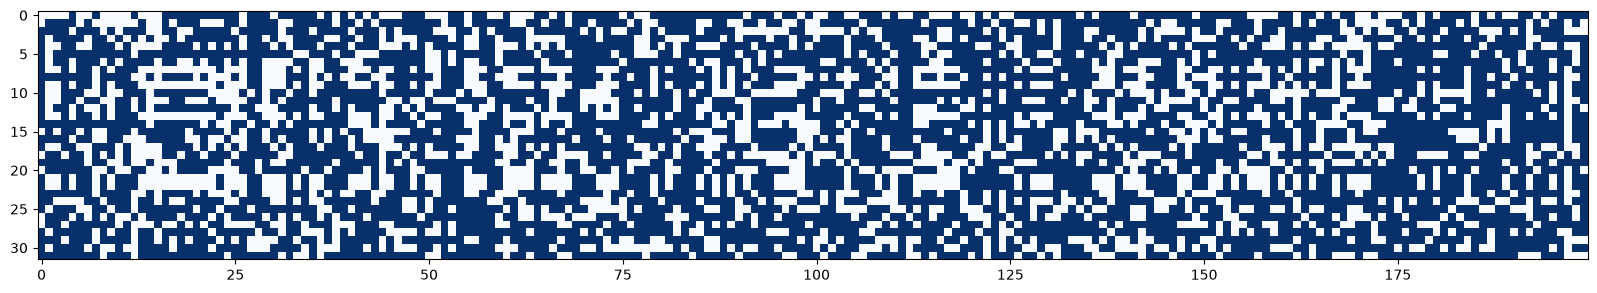

In [17]:
plt.figure(figsize=(20,10))
plt.imshow(h.abs() > 0.99, cmap='Blues', interpolation='nearest')

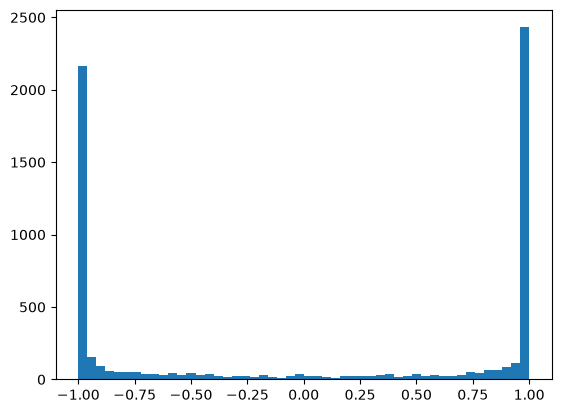

In [18]:
plt.hist(h.view(-1).tolist(), 50);

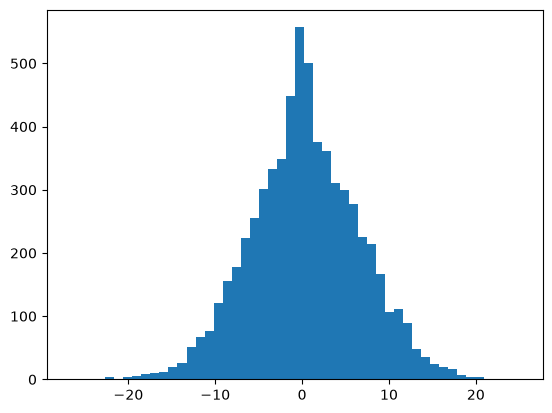

In [19]:
plt.hist(hpreact.view(-1).tolist(), 50);

In [ ]:
# hpreact is too far away from 0. We can fix this by initializing the weights of the hidden layer 
# to be smaller values.

In [20]:
# MLP revisited
n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 200 # the number of neurons in the hidden layer of the MLP

g = torch.Generator().manual_seed(2147483647) # for reproducibility
C  = torch.randn((vocab_size, n_embd),            generator=g)
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) * 0.1
b1 = torch.randn(n_hidden,                        generator=g) * 0.01
W2 = torch.randn((n_hidden, vocab_size),          generator=g) * 0.01
b2 = torch.randn(vocab_size,                      generator=g) * 0

parameters = [C, W1, b1, W2, b2]
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
  p.requires_grad = True

11897


In [21]:
# Same optimization
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):
    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y

    # forward pass
    emb = C[Xb] # embed characters into vectors
    embcat = emb.view(emb.shape[0], -1) # contatenate the vectors
    hpreact = embcat @ W1 + b1 # hidden layer pre-activation
    h = torch.tanh(hpreact) # hidden layer
    logits = h @ W2 + b2 # output layer
    loss = F.cross_entropy(logits, Yb) # loss function

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = 0.1 if i < 100000 else 0.01 # step learning rate decay
    for p in parameters:
        p.data += -lr * p.grad

    # track stats
    if i % 10000 == 0: # print every once in a while
        print(f'{i:7d} /{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())

      0 / 200000: 3.3069
  10000 / 200000: 2.1900
  20000 / 200000: 2.2707
  30000 / 200000: 2.4296
  40000 / 200000: 1.9041
  50000 / 200000: 2.3865
  60000 / 200000: 2.3392
  70000 / 200000: 2.0873
  80000 / 200000: 2.2595
  90000 / 200000: 2.1146
 100000 / 200000: 1.8817
 110000 / 200000: 2.1622
 120000 / 200000: 1.8919
 130000 / 200000: 2.3128
 140000 / 200000: 2.3481
 150000 / 200000: 2.1759
 160000 / 200000: 1.8034
 170000 / 200000: 1.7760
 180000 / 200000: 1.8992
 190000 / 200000: 1.8666


In [22]:
@torch.no_grad() # this decorator disables gradient tracking
def split_loss(split):
  x,y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
  }[split]
  emb = C[x] # (N, block_size, n_embd)
  embcat = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
  hpreact = embcat @ W1 + b1
  h = torch.tanh(hpreact) # (N, n_hidden)
  logits = h @ W2 + b2 # (N, vocab_size)
  loss = F.cross_entropy(logits, y)
  print(split, loss.item())

split_loss('train')
split_loss('val')

train 2.057901382446289
val 2.113706350326538


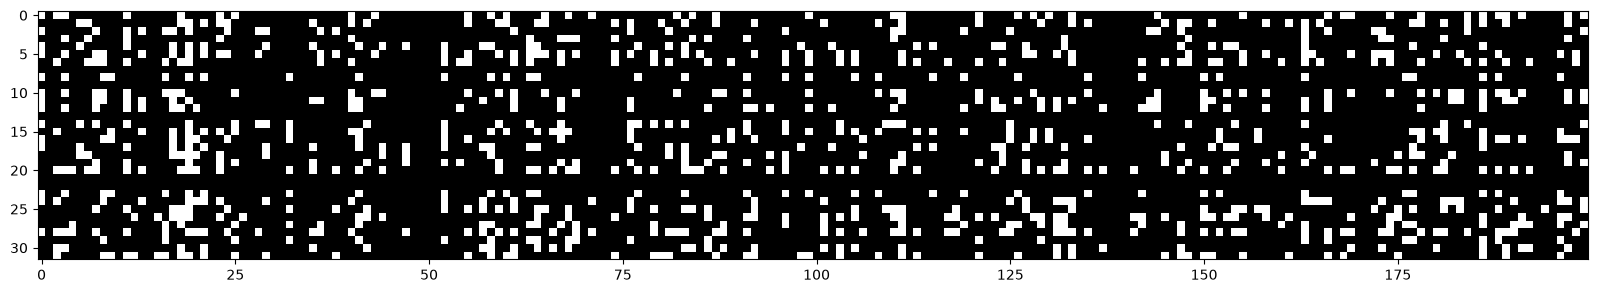

In [23]:
plt.figure(figsize=(20,10))
plt.imshow(h.abs() > 0.99, cmap='gray', interpolation='nearest')

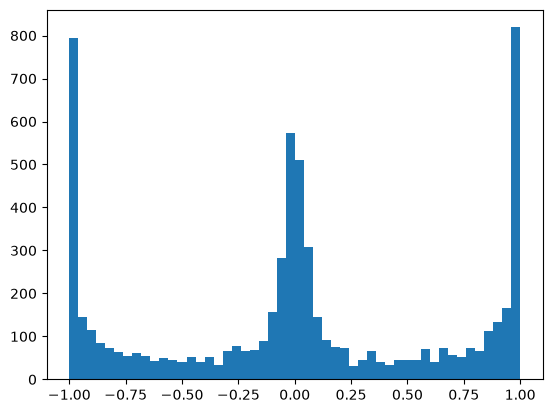

In [24]:
plt.hist(h.view(-1).tolist(), 50);

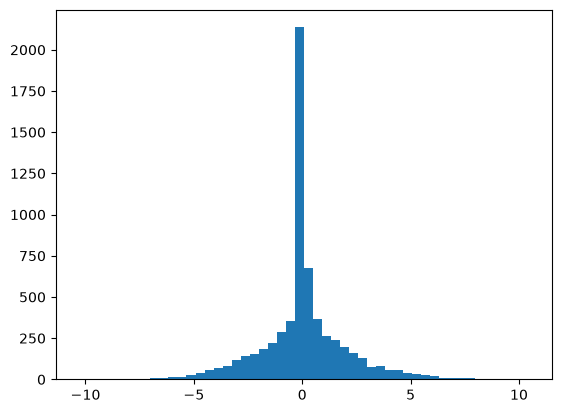

In [25]:
plt.hist(hpreact.view(-1).tolist(), 50);

In [ ]:
# Now we will look at what should be multiplied by hidden layer weights.
# Goal is to set a multiplier such that standard deviation of the hidden layer 
# pre-activation values remains the same.
# The multiplier determines what standard deviation of the hidden layer pre-activation values is.
# Normally, mutiplier is set to 1/sqrt(fan_in) so that the standard deviation of the hidden layer 
# pre-activation values remains close to 1.
# The gain for tanh is 5/3. The fan_in is the number of input neurons to the hidden layer, 
# which is n_embd * block_size.
# So we will set the multiplier of the hidden layer to be 5/3/sqrt(n_embd * block_size).

In [26]:
# Example to show that the standard deviation of the hidden layer pre-activation values remains 
# almost the same when multiplier is set to 1/sqrt(fan_in).
x = torch.randn(10000, 5)
w = torch.randn(5, 200) / 5**0.5
y = x @ w
print(x.mean(), x.std())
print(y.mean(), y.std())
# Refer to torch.nn.init documentation for tanh gain(which is 5/3)

tensor(-0.0020) tensor(1.0016)
tensor(-0.0011) tensor(0.9873)


In [6]:
# MLP revisited
n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 200 # the number of neurons in the hidden layer of the MLP

g = torch.Generator().manual_seed(2147483647) # for reproducibility
C  = torch.randn((vocab_size, n_embd),            generator=g)
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) * (5/3) / (n_embd * block_size)**0.5
b1 = torch.randn(n_hidden,                        generator=g) * 0.01
W2 = torch.randn((n_hidden, vocab_size),          generator=g) * 0.01
b2 = torch.randn(vocab_size,                      generator=g) * 0

parameters = [C, W1, b1, W2, b2]
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
  p.requires_grad = True

11897


In [7]:
# Same optimization
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):
    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y

    # forward pass
    emb = C[Xb] # embed characters into vectors
    embcat = emb.view(emb.shape[0], -1) # contatenate the vectors
    hpreact = embcat @ W1 + b1 # hidden layer pre-activation
    h = torch.tanh(hpreact) # hidden layer
    logits = h @ W2 + b2 # output layer
    loss = F.cross_entropy(logits, Yb) # loss function

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = 0.1 if i < 100000 else 0.01 # step learning rate decay
    for p in parameters:
        p.data += -lr * p.grad

    # track stats
    if i % 10000 == 0: # print every once in a while
        print(f'{i:7d} /{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())

      0 / 200000: 3.3179
  10000 / 200000: 2.1910
  20000 / 200000: 2.3270
  30000 / 200000: 2.5396
  40000 / 200000: 1.9468
  50000 / 200000: 2.3331
  60000 / 200000: 2.3852
  70000 / 200000: 2.1173
  80000 / 200000: 2.3159
  90000 / 200000: 2.2010
 100000 / 200000: 1.8591
 110000 / 200000: 2.0881
 120000 / 200000: 1.9389
 130000 / 200000: 2.3913
 140000 / 200000: 2.0949
 150000 / 200000: 2.1458


KeyboardInterrupt: 

In [29]:
@torch.no_grad() # this decorator disables gradient tracking
def split_loss(split):
  x,y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
  }[split]
  emb = C[x] # (N, block_size, n_embd)
  embcat = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
  hpreact = embcat @ W1 + b1
  h = torch.tanh(hpreact) # (N, n_hidden)
  logits = h @ W2 + b2 # (N, vocab_size)
  loss = F.cross_entropy(logits, y)
  print(split, loss.item())

split_loss('train')
split_loss('val')

train 2.0376644134521484
val 2.106989622116089


In [ ]:
# Precise setting of hidden layer weights initialization is not as important due some
# mordern innovations like batch normalization, layer normalization, residual connections, etc.
# Batch normalization -
# The paper says that take the hidden states and normalize to be gaussian.
# To do this - Subtract the mean(along 0th dimension) and divide by standard deviation.
# Just with this you will not achieve good results as we want them to be rougly gaussion but only
# at initialization. We would like the neural network to move them around and the back propagation to
# tell how where to move them. So we will add a learnable parameter to scale and 
# shift the normalized values.
# So according to the paper, we will "scale and shift".

In [6]:
# MLP revisited
n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 200 # the number of neurons in the hidden layer of the MLP

g = torch.Generator().manual_seed(2147483647) # for reproducibility
C  = torch.randn((vocab_size, n_embd),            generator=g)
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) * (5/3) / (n_embd * block_size)**0.5
# Dont need it as bnbias is handling the bias so it will get subtracted anyway.
# b1 = torch.randn(n_hidden,                        generator=g) * 0.01
W2 = torch.randn((n_hidden, vocab_size),          generator=g) * 0.01
b2 = torch.randn(vocab_size,                      generator=g) * 0

bngain = torch.ones((1, n_hidden)) # for scaling 
bnbias = torch.zeros((1, n_hidden)) # for shifting
bnmean_running = torch.zeros((1, n_hidden)) # running mean
bnstd_running = torch.ones((1, n_hidden)) # running std

parameters = [C, W1, W2, b2, bngain, bnbias] # removed b1
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
  p.requires_grad = True

12097


In [7]:
# Same optimization
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):
    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y

    # forward pass
    emb = C[Xb] # embed characters into vectors
    embcat = emb.view(emb.shape[0], -1) # contatenate the vectors
    # Linear Layer
    hpreact = embcat @ W1 # + b1 # hidden layer pre-activation
    # batch normalization
    bnmeani = hpreact.mean(0, keepdim=True)
    bnstdi = hpreact.std(0, keepdim=True)
    hpreact = bngain * (hpreact - bnmeani) / bnstdi + bnbias
    # running mean and std are not part of gradient based optimization.
    with torch.no_grad():
        bnmean_running = 0.999 * bnmean_running + 0.001 * bnmeani
        bnstd_running = 0.999 * bnstd_running + 0.001 * bnstdi
    
    h = torch.tanh(hpreact) # hidden layer
    logits = h @ W2 + b2 # output layer
    loss = F.cross_entropy(logits, Yb) # loss function

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = 0.1 if i < 100000 else 0.01 # step learning rate decay
    for p in parameters:
        p.data += -lr * p.grad

    # track stats
    if i % 10000 == 0: # print every once in a while
        print(f'{i:7d} /{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())

      0 / 200000: 3.3239
  10000 / 200000: 2.0322
  20000 / 200000: 2.5675
  30000 / 200000: 2.0125
  40000 / 200000: 2.2446
  50000 / 200000: 1.8897
  60000 / 200000: 2.0785
  70000 / 200000: 2.3681
  80000 / 200000: 2.2918
  90000 / 200000: 2.0238
 100000 / 200000: 2.3673
 110000 / 200000: 2.3132
 120000 / 200000: 1.6414
 130000 / 200000: 1.9311
 140000 / 200000: 2.2231
 150000 / 200000: 2.0027
 160000 / 200000: 2.0997
 170000 / 200000: 2.4949
 180000 / 200000: 2.0199
 190000 / 200000: 2.1707


In [ ]:
# Once we train a neural network and deploy it, we would like to feed a single input and get 
# a prediction out. But during our training(forward pass), we estimate mean and standard deviation 
# over batches so neural network expects batches as input.
# So how do we feed in a single example and get a prediction out? 
# In the paper, we introduce a step after training as shown below -
# So during test time we will estimate the mean and standard deviation over the entire training set 
# and use those fix values and use them during inference.
# The results are the same but difference is that we can forward a single example and get a prediction out.
# Since no one wants to add 1 more step to the training, here is 1 more idea from the paper.
# We can calculate mean and standard deviation in a running manner during training.
# Expectation is that during training the running mean and standard devialtion are very close to the mean
# and standard deviation over the entire training set so we dont need to add 1 more step to the training.

In [10]:
# calibrate the batch norm at the end of training

with torch.no_grad():
  # pass the training set through
  emb = C[Xtr]
  embcat = emb.view(emb.shape[0], -1)
  hpreact = embcat @ W1 # + b1
  # measure the mean/std over the entire training set
  bnmean = hpreact.mean(0, keepdim=True)
  bnstd = hpreact.std(0, keepdim=True)

In [ ]:
# Now we can compare bnmean_running and bnmean and bnstd_running and bnstd.
# Since both are identical, we dont need another stage of training.

In [8]:
@torch.no_grad() # this decorator disables gradient tracking
def split_loss(split):
  x,y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
  }[split]
  emb = C[x] # (N, block_size, n_embd)
  embcat = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
  hpreact = embcat @ W1 # + b1
  # batch normalization
  # hpreact = bngain * (hpreact - hpreact.mean(0, keepdim=True)) / hpreact.std(0, keepdim=True) + bnbias
  hpreact = bngain * (hpreact - bnmean_running) / bnstd_running + bnbias
  h = torch.tanh(hpreact) # (N, n_hidden)
  logits = h @ W2 + b2 # (N, vocab_size)
  loss = F.cross_entropy(logits, y)
  print(split, loss.item())

split_loss('train')
split_loss('val')

train 2.0674145221710205
val 2.1056840419769287


In [ ]:
# Improvement due to batch normalization is not expected here as its a very small network.
# Since we were are able to scale W1 properly, the values already have a roughly gaussian distribution 
# and the batch normalization will not have much effect. 
# When the network is deeper, the batch normalization will have more effect as the values will be 
# more skewed and not gaussian.
# Due to us using minibatches to train, the batch normalization introduces some noise in the training 
# which can help with generalization. It looks like a bug but its actually a regularization technique.
# So in the example above, the value of h and logits jitter around a bit which makes it hard for neural
# networks to overfit.

In [12]:
# Let's train a deeper network
# The classes we create here are the same API as nn.Module in PyTorch

class Linear:
  
  # fan_in - number of input neurons to the layer
  # fan_out - number of output neurons from the layer
  def __init__(self, fan_in, fan_out, bias=True): 
    self.weight = torch.randn((fan_in, fan_out), generator=g) / fan_in**0.5
    self.bias = torch.zeros(fan_out) if bias else None
  
  def __call__(self, x):
    self.out = x @ self.weight
    if self.bias is not None:
      self.out += self.bias
    return self.out
  
  def parameters(self):
    return [self.weight] + ([] if self.bias is None else [self.bias])
  
class BatchNorm1d:
  
  def __init__(self, dim, eps=1e-5, momentum=0.1):
    self.eps = eps
    self.momentum = momentum
    self.training = True
    # parameters (trained with backprop)
    self.gamma = torch.ones(dim)
    self.beta = torch.zeros(dim)
    # buffers (trained with a running 'momentum update')
    self.running_mean = torch.zeros(dim)
    self.running_var = torch.ones(dim)
  
  def __call__(self, x):
    # calculate the forward pass
    if self.training:
      xmean = x.mean(0, keepdim=True) # batch mean
      xvar = x.var(0, keepdim=True) # batch variance
    else:
      xmean = self.running_mean
      xvar = self.running_var
    xhat = (x - xmean) / torch.sqrt(xvar + self.eps) # normalize to unit variance
    self.out = self.gamma * xhat + self.beta
    # update the buffers
    if self.training:
      with torch.no_grad():
        self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
        self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar
    return self.out
  
  def parameters(self):
    return [self.gamma, self.beta]
  
class Tanh:
  def __call__(self, x):
    self.out = torch.tanh(x)
    return self.out
  def parameters(self):
    return []

n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 100 # the number of neurons in the hidden layer of the MLP
g = torch.Generator().manual_seed(2147483647) # for reproducibility

C = torch.randn((vocab_size, n_embd),            generator=g)
layers = [
  Linear(n_embd * block_size, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  Linear(           n_hidden, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  Linear(           n_hidden, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  Linear(           n_hidden, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  Linear(           n_hidden, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  Linear(           n_hidden, vocab_size, bias=False), BatchNorm1d(vocab_size),
]
# layers = [
#   Linear(n_embd * block_size, n_hidden), Tanh(),
#   Linear(           n_hidden, n_hidden), Tanh(),
#   Linear(           n_hidden, n_hidden), Tanh(),
#   Linear(           n_hidden, n_hidden), Tanh(),
#   Linear(           n_hidden, n_hidden), Tanh(),
#   Linear(           n_hidden, vocab_size),
# ]

with torch.no_grad():
  # last layer: make less confident
  layers[-1].gamma *= 0.1
  # layers[-1].weight *= 0.1
  # all other layers: apply gain
  for layer in layers[:-1]:
    if isinstance(layer, Linear):
      layer.weight *= 5/3

parameters = [C] + [p for layer in layers for p in layer.parameters()]
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
  p.requires_grad = True

47024


In [13]:
#same optimization as last time
max_steps = 200000
batch_size = 32
lossi = []
ud = []

for i in range(max_steps):
  
  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
  Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y
  
  # forward pass
  emb = C[Xb] # embed the characters into vectors
  x = emb.view(emb.shape[0], -1) # concatenate the vectors
  for layer in layers:
    x = layer(x)
  loss = F.cross_entropy(x, Yb) # loss function
  
  # backward pass
  for layer in layers:
    layer.out.retain_grad() # AFTER_DEBUG: would take out retain_graph
  for p in parameters:
    p.grad = None
  loss.backward()
  
  # update
  lr = 0.1 if i < 150000 else 0.01 # step learning rate decay
  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  if i % 10000 == 0: # print every once in a while
    print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
  lossi.append(loss.log10().item())
  with torch.no_grad():
    ud.append([((lr*p.grad).std() / p.data.std()).log10().item() for p in parameters])

  # if i >= 1000:
  #   break # AFTER_DEBUG: would take out obviously to run full optimization


      0/ 200000: 3.2870
  10000/ 200000: 2.3578
  20000/ 200000: 2.1042
  30000/ 200000: 1.9646
  40000/ 200000: 2.2144
  50000/ 200000: 2.2263
  60000/ 200000: 1.7340
  70000/ 200000: 2.1744
  80000/ 200000: 2.1895
  90000/ 200000: 1.8283
 100000/ 200000: 2.3644
 110000/ 200000: 2.2596
 120000/ 200000: 2.0967
 130000/ 200000: 1.8993
 140000/ 200000: 1.8313
 150000/ 200000: 1.9430
 160000/ 200000: 1.8673
 170000/ 200000: 1.8335
 180000/ 200000: 2.2504
 190000/ 200000: 2.0148


layer 2 (      Tanh): mean -0.01, std 0.70, saturated: 16.34%
layer 5 (      Tanh): mean -0.02, std 0.74, saturated: 19.19%
layer 8 (      Tanh): mean -0.00, std 0.77, saturated: 19.09%
layer 11 (      Tanh): mean +0.02, std 0.79, saturated: 20.84%
layer 14 (      Tanh): mean -0.01, std 0.81, saturated: 23.16%


Text(0.5, 1.0, 'activation distribution')

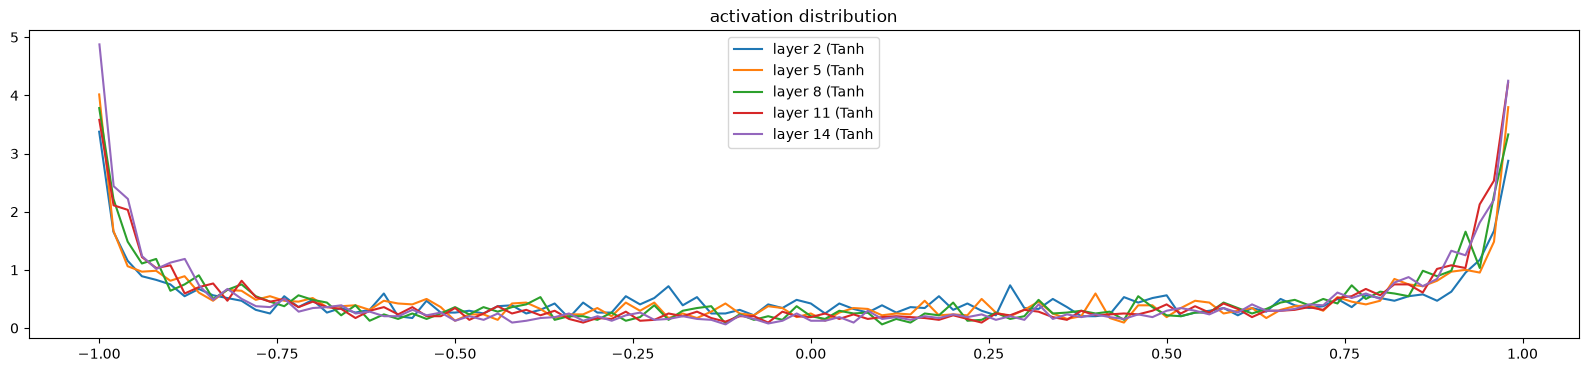

In [15]:
# visualize histograms
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i, layer in enumerate(layers[:-1]): # note: exclude the output layer
  if isinstance(layer, Tanh):
    t = layer.out
    print('layer %d (%10s): mean %+.2f, std %.2f, saturated: %.2f%%' % (i, layer.__class__.__name__, t.mean(), t.std(), (t.abs() > 0.97).float().mean()*100))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'layer {i} ({layer.__class__.__name__}')
plt.legend(legends);
plt.title('activation distribution')

layer 2 (      Tanh): mean -0.000000, std 3.181885e-03
layer 5 (      Tanh): mean +0.000000, std 3.067913e-03
layer 8 (      Tanh): mean +0.000000, std 3.131268e-03
layer 11 (      Tanh): mean -0.000000, std 3.453576e-03
layer 14 (      Tanh): mean +0.000000, std 3.800671e-03


Text(0.5, 1.0, 'gradient distribution')

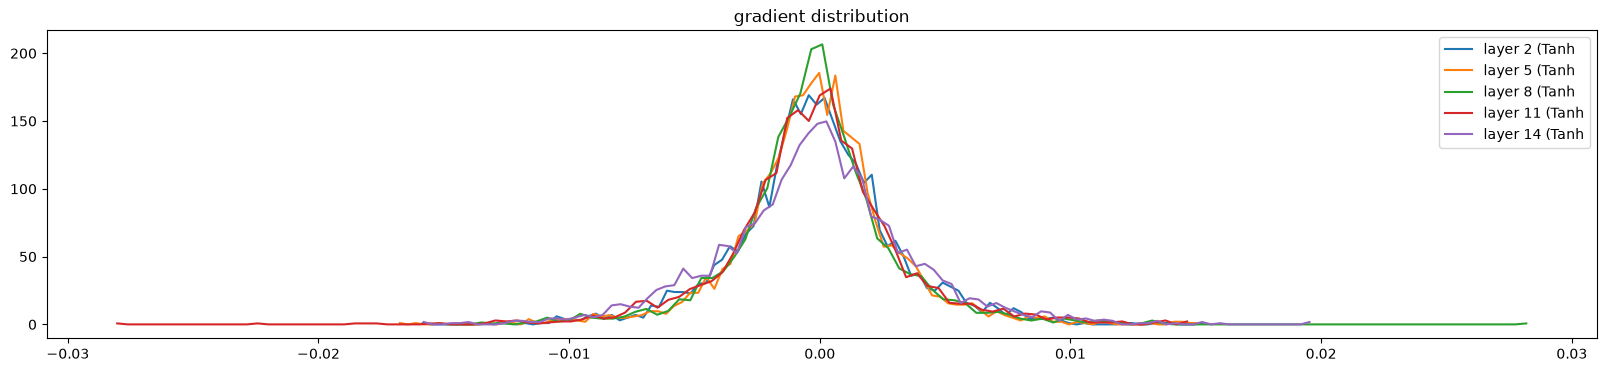

In [16]:
# visualize histograms
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i, layer in enumerate(layers[:-1]): # note: exclude the output layer
  if isinstance(layer, Tanh):
    t = layer.out.grad
    print('layer %d (%10s): mean %+f, std %e' % (i, layer.__class__.__name__, t.mean(), t.std()))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'layer {i} ({layer.__class__.__name__}')
plt.legend(legends);
plt.title('gradient distribution')

weight   (27, 10) | mean +0.000000 | std 1.369372e-02 | grad:data ratio 1.194312e-02
weight  (30, 100) | mean +0.000061 | std 6.415409e-03 | grad:data ratio 1.430622e-02
weight (100, 100) | mean +0.000060 | std 4.184393e-03 | grad:data ratio 1.534993e-02
weight (100, 100) | mean -0.000077 | std 4.404041e-03 | grad:data ratio 1.640474e-02
weight (100, 100) | mean +0.000021 | std 4.559188e-03 | grad:data ratio 1.746905e-02
weight (100, 100) | mean -0.000019 | std 4.729874e-03 | grad:data ratio 1.877286e-02
weight  (100, 27) | mean +0.000046 | std 8.239143e-03 | grad:data ratio 2.210231e-02


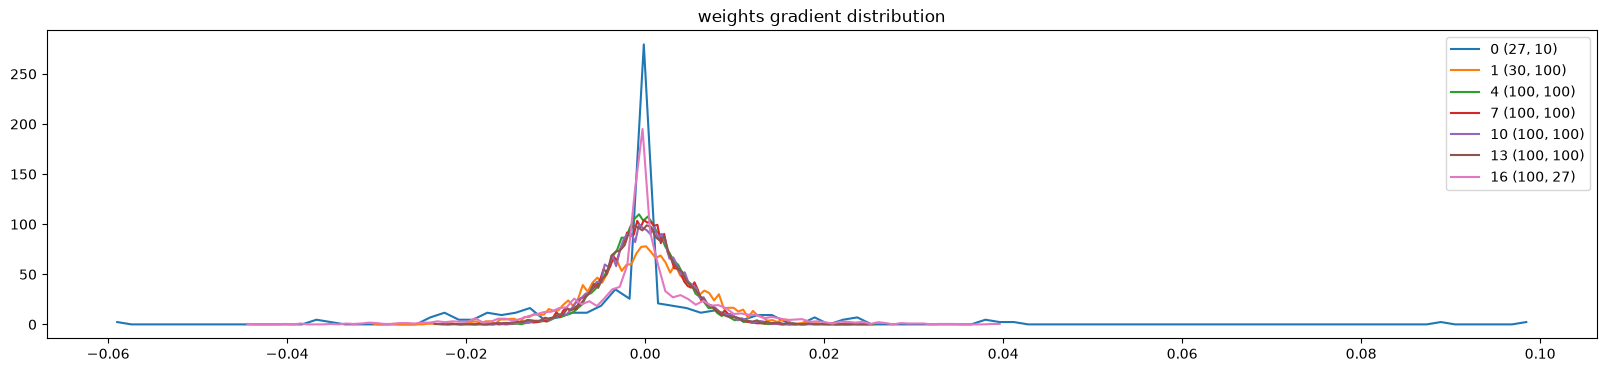

In [17]:
# visualize histograms
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i,p in enumerate(parameters):
  t = p.grad
  if p.ndim == 2:
    print('weight %10s | mean %+f | std %e | grad:data ratio %e' % (tuple(p.shape), t.mean(), t.std(), t.std() / p.std()))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'{i} {tuple(p.shape)}')
plt.legend(legends)
plt.title('weights gradient distribution');

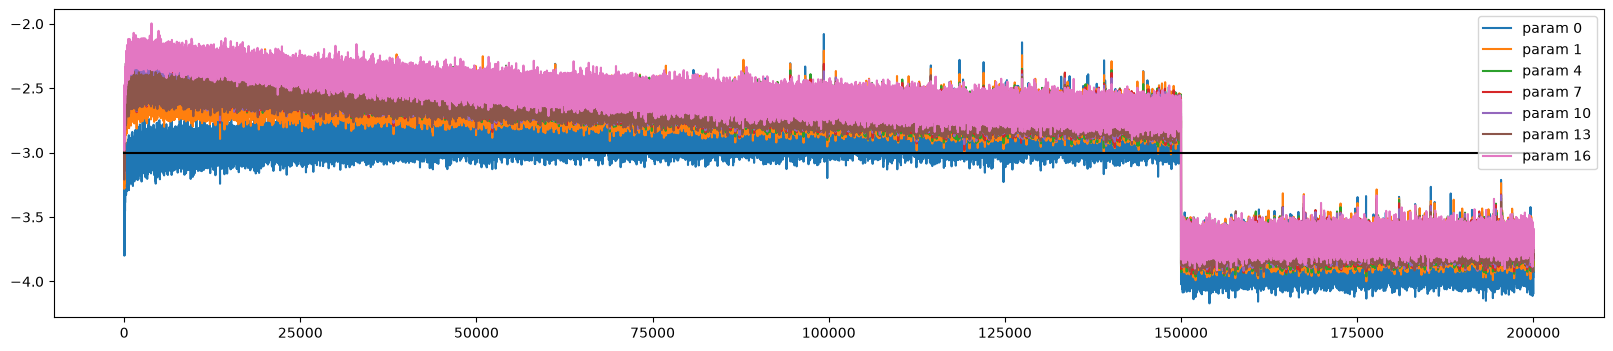

In [18]:
plt.figure(figsize=(20, 4))
legends = []
for i,p in enumerate(parameters):
  if p.ndim == 2:
    plt.plot([ud[j][i] for j in range(len(ud))])
    legends.append('param %d' % i)
plt.plot([0, len(ud)], [-3, -3], 'k') # these ratios should be ~1e-3, indicate on plot
plt.legend(legends);

In [19]:
@torch.no_grad() # this decorator disables gradient tracking
def split_loss(split):
  x,y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
  }[split]
  emb = C[x] # (N, block_size, n_embd)
  x = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
  for layer in layers:
    x = layer(x)
  loss = F.cross_entropy(x, y)
  print(split, loss.item())

# put layers into eval mode
for layer in layers:
  layer.training = False
split_loss('train')
split_loss('val')

train 2.003948211669922
val 2.080596923828125


In [20]:
# sample from the model
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):
    
    out = []
    context = [0] * block_size # initialize with all ...
    while True:
      # forward pass the neural net
      emb = C[torch.tensor([context])] # (1,block_size,n_embd)
      x = emb.view(emb.shape[0], -1) # concatenate the vectors
      for layer in layers:
        x = layer(x)
      logits = x
      probs = F.softmax(logits, dim=1)
      # sample from the distribution
      ix = torch.multinomial(probs, num_samples=1, generator=g).item()
      # shift the context window and track the samples
      context = context[1:] + [ix]
      out.append(ix)
      # if we sample the special '.' token, break
      if ix == 0:
        break
    
    print(''.join(itos[i] for i in out)) # decode and print the generated word

carmahfari.
harlin.
mili.
tatyah.
cassie.
rah.
bradheryncia.
qui.
nellara.
chaiivia.
legyn.
ham.
joce.
quintis.
lilah.
jadilyn.
jero.
dearyn.
kai.
eveiluan.
